# Environmental Data Analytics

## Week 1: Data Collection & Initial Exploration

### Capstone Project – EcoSphere Institute

Group Number: 14
Capstone Project – Environmental Data Analytics
EcoSphere Institute

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# Load Datasets

temp_df = pd.read_csv("Temperature_Data.csv")
aq_df = pd.read_csv("Air_Quality_Data.csv")
geo_df = pd.read_csv("Geospatial_Data.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [52]:
#Dataset Shapes

print("Temperature Dataset Shape:", temp_df.shape)
print("Air Quality Dataset Shape:", aq_df.shape)
print("Geospatial Dataset Shape:", geo_df.shape)

Temperature Dataset Shape: (148, 1)
Air Quality Dataset Shape: (29531, 16)
Geospatial Dataset Shape: (6159, 4)


In [53]:
#Dataset Column names
print("Temperature Columns:")
print(temp_df.columns.tolist())

print("\nAir Quality Columns:")
print(aq_df.columns.tolist())

print("\nGeospatial Columns:")
print(geo_df.columns.tolist())

Temperature Columns:
['Land-Ocean: Global Means']

Air Quality Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Geospatial Columns:
['Land', 'Year', 'Series', 'Value']


In [54]:
#DataSet Preview
print("Temperature Dataset")
display(temp_df.head())

print("\nAir Quality Dataset")
display(aq_df.head())

print("\nGeospatial Dataset")
display(geo_df.head())

Temperature Dataset


,,,,,,,,,,,,,,,,,,Land-Ocean: Global Means
Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1880,-.19,-.25,-.10,-.17,-.10,-.21,-.19,-.11,-.15,-.24,-.22,-.19,-.18,***,***,-.12,-.17,-.20
1881,-.20,-.16,.02,.04,.06,-.19,.01,-.04,-.15,-.22,-.19,-.07,-.09,-.10,-.18,.04,-.07,-.18
1882,.16,.14,.04,-.16,-.14,-.22,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.08,-.15,-.18
1883,-.29,-.36,-.12,-.18,-.17,-.07,-.07,-.14,-.22,-.11,-.24,-.11,-.17,-.20,-.34,-.16,-.09,-.19



Air Quality Dataset


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



Geospatial Dataset


,Land,Year,Series,Value
0,"Total, all countries or areas",2005,Land area (thousand hectares),1.299769e+07
1,"Total, all countries or areas",2005,Arable land (thousand hectares),1.356869e+06
2,"Total, all countries or areas",2005,Permanent crops (thousand hectares),1.456805e+05
3,"Total, all countries or areas",2005,Forest cover (thousand hectares),4.032743e+06
4,"Total, all countries or areas",2005,Arable land (% of total land area),1.043930e+01


A missing value assessment was performed to identify data quality issues prior to preprocessing.

In [55]:
#Missing Value Analysis
print("Temperature Missing Values")
print(temp_df.isnull().sum())

print("\nAir Quality Missing Values")
print(aq_df.isnull().sum())

print("\nGeospatial Missing Values")
print(geo_df.isnull().sum())

Temperature Missing Values
Land-Ocean: Global Means    0
dtype: int64

Air Quality Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Geospatial Missing Values
Land      0
Year      0
Series    0
Value     0
dtype: int64


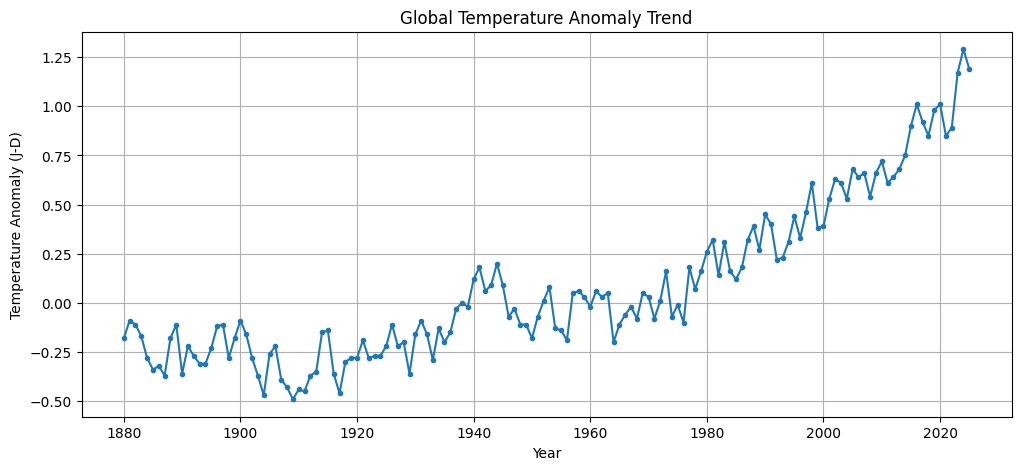

In [56]:
# Temperature Trend Graph
# Convert the index (years) and J-D column to numeric

temp_plot = temp_df.copy()

temp_plot = temp_plot.reset_index()

# Rename columns for convenience
temp_plot.columns = ['Year','Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec',
                     'J-D','D-N','DJF','MAM','JJA','SON']

temp_plot['Year'] = pd.to_numeric(temp_plot['Year'], errors='coerce')
temp_plot['J-D'] = pd.to_numeric(temp_plot['J-D'], errors='coerce')

plt.figure(figsize=(12,5))
plt.plot(temp_plot['Year'], temp_plot['J-D'], marker='.')

plt.title('Global Temperature Anomaly Trend')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (J-D)')
plt.grid(True)

plt.show()

Temperature Graph Insight: Global temperature anomalies show a clear upward trend, particularly after 1980, indicating long-term warming.

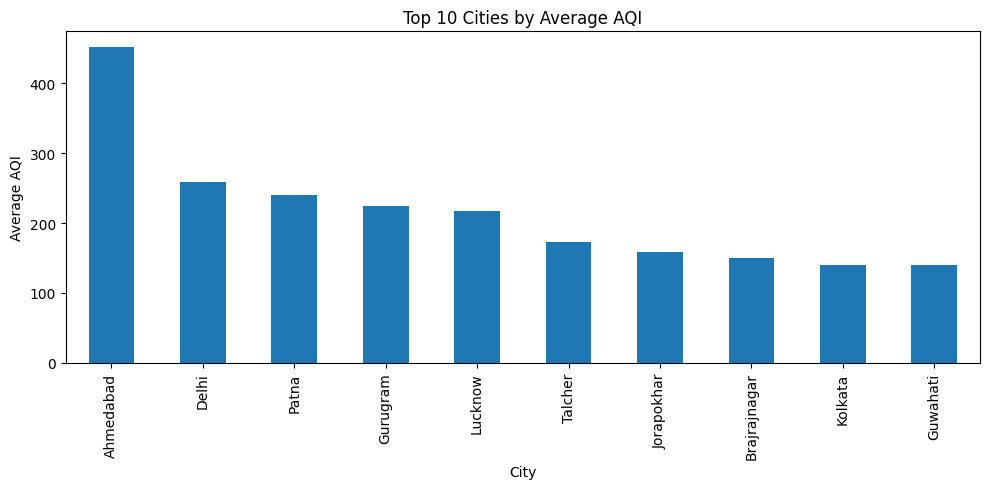

In [57]:
#Air Quality Graph
city_aqi = (
    aq_df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
city_aqi.plot(kind="bar")

plt.title("Top 10 Cities by Average AQI")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

AQI Graph Insight: Ahmedabad records the highest average AQI among the top 10 cities analyzed.

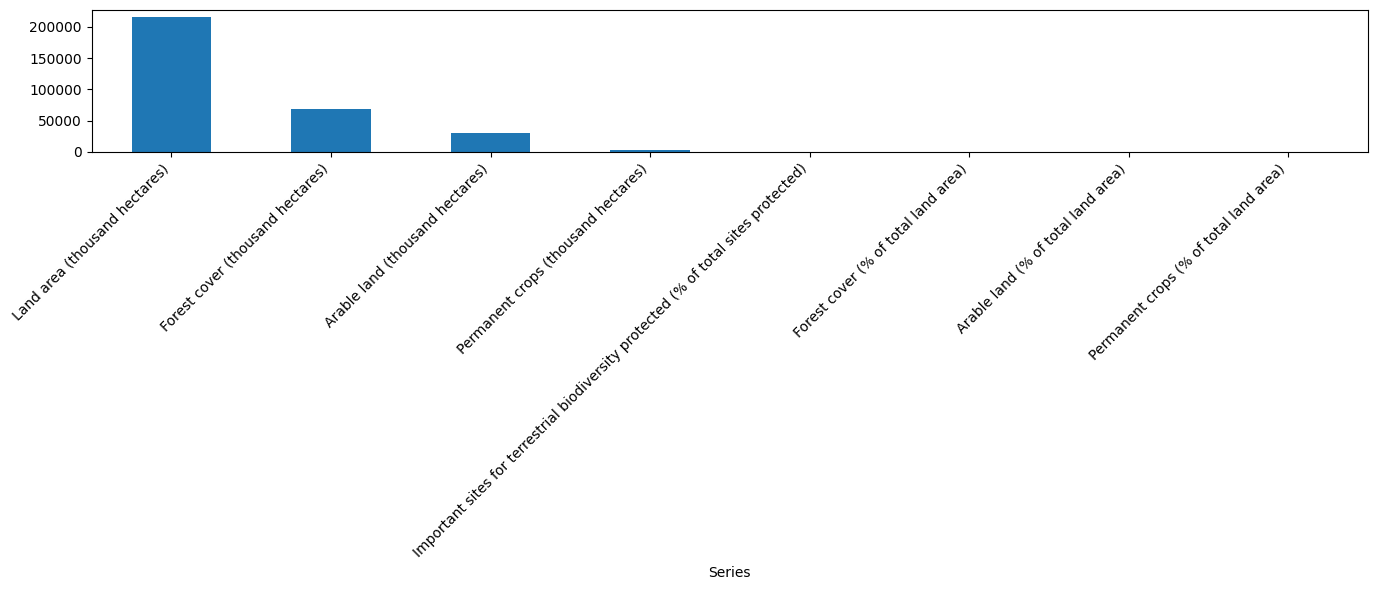

In [58]:
# Geospatial Graph

geo_summary = (
    geo_df.groupby("Series")["Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))
geo_summary.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Geospatial Graph Insight: Land area and forest cover indicators contribute the largest values in the geospatial dataset.

# Observations

### Temperature Dataset

- The global temperature anomaly dataset shows a clear long-term warming trend from 1880 to the present.
- Temperature anomalies increased significantly after 1980.
- Recent years exhibit the highest recorded temperature anomalies, indicating accelerating global warming patterns.

### Air Quality Dataset
- Significant variation in AQI values was observed across cities.
- Ahmedabad recorded the highest average AQI among the top 10 cities analyzed.
- The dataset contains several missing values that will be handled during preprocessing.

### Geospatial Dataset
- Land area and forest cover indicators dominate the environmental dataset.
- Environmental indicators vary considerably across regions and land-use categories.
- The dataset appears complete with no missing values.

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Visual Studio Code

# Conclusion

Week 1 focused on identifying, collecting, and performing initial exploration of environmental datasets.

Three datasets covering temperature, air quality, and geospatial indicators were successfully acquired and analyzed.

Initial exploratory analysis provided insights into dataset structure, missing values, environmental indicators, and urban air quality patterns.

These findings establish a strong foundation for data cleaning, preprocessing, and integration activities planned for Week 2.

Week 2 will focus on data cleaning, preprocessing, handling missing values, and integrating the datasets for further analysis.